In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

In [2]:
DATA_PATH = "../data/raw/divar.csv"
df = pd.read_csv(DATA_PATH)

C:\Users\IRANA COMPUTER\AppData\Local\Temp\ipykernel_15060\1138651529.py:2: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


In [3]:
luxury_cols = [
    "has_pool",
    "has_barbecue",
    "has_jacuzzi",
    "has_sauna"
]

In [4]:
hyp4_cols = [
    "price_value"
] + luxury_cols

df_hyp4 = df[hyp4_cols].copy()

df_hyp4.head()

,price_value,has_pool,has_barbecue,has_jacuzzi,has_sauna
0,NaN,NaN,NaN,NaN,NaN
1,8.500000e+09,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,5.750000e+09,NaN,NaN,NaN,NaN


In [5]:
df_hyp4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price_value   568346 non-null  float64
 1   has_pool      29390 non-null   object 
 2   has_barbecue  31198 non-null   object 
 3   has_jacuzzi   28728 non-null   object 
 4   has_sauna     28479 non-null   object 
dtypes: float64(1), object(4)
memory usage: 38.1+ MB


In [6]:
for col in luxury_cols:
    print(f"\nColumn: {col}")
    print(df_hyp4[col].value_counts(dropna=False))
    print("-" * 50)


Column: has_pool
has_pool
NaN      970610
False     25669
True       3721
Name: count, dtype: int64
--------------------------------------------------

Column: has_barbecue
has_barbecue
NaN      968802
False     23377
True       7821
Name: count, dtype: int64
--------------------------------------------------

Column: has_jacuzzi
has_jacuzzi
NaN      971272
False     26455
True       2273
Name: count, dtype: int64
--------------------------------------------------

Column: has_sauna
has_sauna
NaN      971521
False     27084
True       1395
Name: count, dtype: int64
--------------------------------------------------


We keep only rows with a valid positive price because the hypothesis test compares mean prices.

In [8]:
df_hyp4 = df_hyp4[
    df_hyp4["price_value"].notna() &
    (df_hyp4["price_value"] > 0)
].copy()

df_hyp4.shape

(566444, 5)

We define a Ad as luxury if it has at least one luxury amenity

In [16]:
df_hyp4 = df_hyp4[
    df_hyp4[luxury_cols].notna().any(axis=1)
].copy()

df_hyp4.shape

(21918, 6)

Ads with all luxury amenity values missing are removed because their luxury status is unknown.

In [17]:
df_hyp4["has_luxury"].value_counts(dropna=False)

has_luxury
False    15665
True      6253
Name: count, dtype: int64

In [33]:
luxury_ads = df_hyp4[df_hyp4["has_luxury"] == True].copy()
non_luxury_ads = df_hyp4[df_hyp4["has_luxury"] == False].copy()

In [23]:
df_hyp4.groupby("has_luxury")["price_value"].describe()

,count,mean,std,min,25%,50%,75%,max
has_luxury,,,,,,,,
False,15665.0,1.543494e+10,8.171339e+11,1.0,1.500000e+09,2.700000e+09,5.000000e+09,1.000000e+14
True,6253.0,1.168298e+10,2.911757e+11,1.0,1.800000e+09,3.000000e+09,5.800000e+09,2.000000e+13


it seems there is some outliers (by comparing min values and max values)

We remove the bottom 2% and top 2% of prices from each group

In [34]:
luxury_lower = luxury_ads["price_value"].quantile(0.02)
luxury_upper = luxury_ads["price_value"].quantile(0.98)

non_luxury_lower = non_luxury_ads["price_value"].quantile(0.02)
non_luxury_upper = non_luxury_ads["price_value"].quantile(0.98)

luxury_ads_clean = luxury_ads[
    luxury_ads["price_value"].between(luxury_lower, luxury_upper)
].copy()

non_luxury_ads_clean = non_luxury_ads[
    non_luxury_ads["price_value"].between(non_luxury_lower, non_luxury_upper)
].copy()

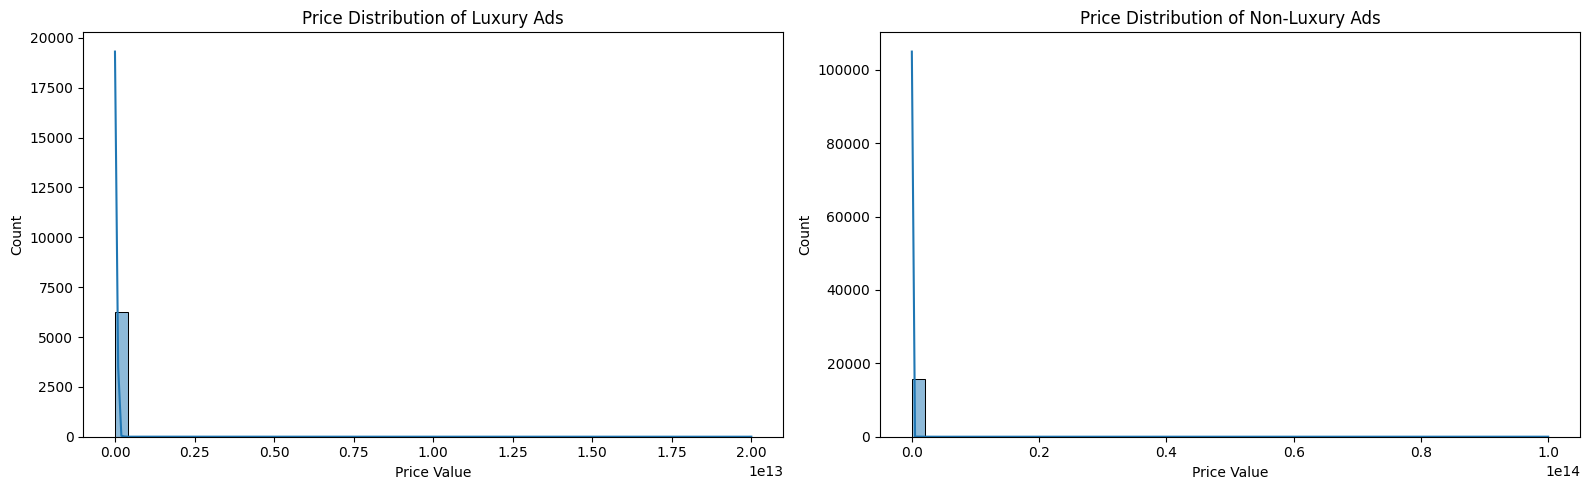

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    luxury_ads["price_value"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Price Distribution of Luxury Ads")
axes[0].set_xlabel("Price Value")
axes[0].set_ylabel("Count")

sns.histplot(
    non_luxury_ads["price_value"],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Price Distribution of Non-Luxury Ads")
axes[1].set_xlabel("Price Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

as you can see in the histogram plots, the range between the minimum and maximum values is still large. To improve this problem, we use the log of the price value column.

In [37]:
luxury_ads_clean['log_price'] = np.log1p(luxury_ads_clean["price_value"])
non_luxury_ads_clean['log_price'] = np.log1p(non_luxury_ads_clean["price_value"])

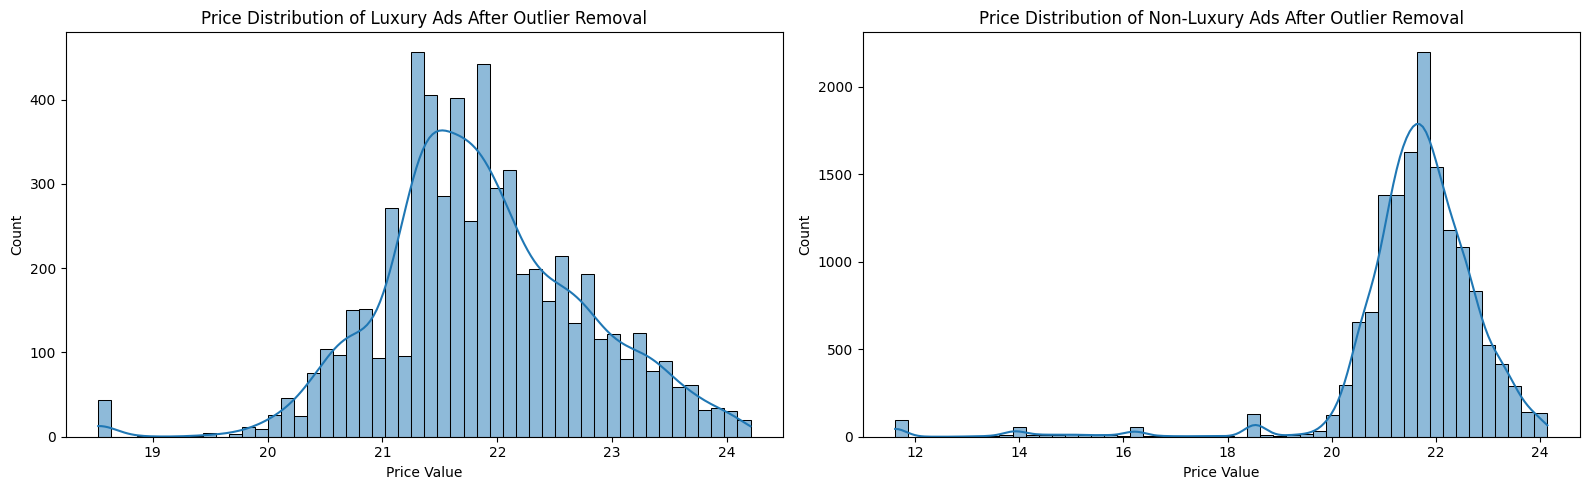

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    luxury_ads_clean["log_price"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Price Distribution of Luxury Ads After Outlier Removal")
axes[0].set_xlabel("Price Value")
axes[0].set_ylabel("Count")

sns.histplot(
    non_luxury_ads_clean["log_price"],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Price Distribution of Non-Luxury Ads After Outlier Removal")
axes[1].set_xlabel("Price Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Hypothesis Test

We want to investigate whether there is a statistically significant difference in the mean sale price of ads based on having luxury amenities.

- **Null Hypothesis (H₀):**  
  There is no statistically significant difference in the mean sale price between ads with luxury amenities and ads without luxury amenities.

$$
  H_0: \mu_{\text{luxury}} = \mu_{\text{not luxury}}
  $$

- **Alternative Hypothesis (H₁):**  
 There is a statistically significant difference in the mean sale price between ads with luxury amenities and ads without luxury amenities.

  $$
  H_1: \mu_{\text{luxury}} \neq \mu_{\text{not luxury}}
  $$

In [40]:
price_luxury = luxury_ads_clean['log_price'] 
price_not_luxury = non_luxury_ads_clean['log_price'] 

In [42]:
stat_luxury, p_luxury = shapiro(price_luxury)
stat_not_luxury, p_not_luxury = shapiro(price_not_luxury)

alpha = 0.05
print("-" * 50)
print('result : ')
if p_luxury > alpha:
    print("not_luxury group looks normally distributed")
else:
    print("not_luxury group does NOT look normally distributed")

if p_not_luxury > alpha:
    print("luxury group looks normally distributed")
else:
    print("luxury group does NOT look normally distributed")

--------------------------------------------------
result : 
not_luxury group does NOT look normally distributed
luxury group does NOT look normally distributed


Since the price distributions are not normal, we use the Mann-Whitney U test as a non-parametric test to compare luxury and non-luxury ads.

In [43]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(price_luxury, price_not_luxury, alternative="two-sided")

In [45]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a statistically significant difference between luxury and non-luxury ads mean price.")
else:
    print("Fail to reject H0: There is not enough evidence to show a statistically significant difference between luxury and non-luxury ads.")

Reject H0: There is a statistically significant difference between luxury and non-luxury ads mean price.
